# analyses of the digit span task data from the delay condition

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_1samp

from collections import Counter


In [9]:
# load
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/07052026_pilot_2_delayed_memory_digit_span_no_feedback/all_digit_span.csv").copy()
save_path = "/mnt/hdd/anatkorol/Imagination_in_translation/analysis/pilot-2_delayed-memory-no-feedback/digit_span"

In [4]:
df.columns

Index(['uid', 'session', 'trial_num', 'sequence_length', 'presented_sequence',
       'participant_response', 'response_time_ms', 'timestamp', 'study_result',
       'comp_result'],
      dtype='object')

In [5]:
df

,uid,session,trial_num,sequence_length,presented_sequence,participant_response,response_time_ms,timestamp,study_result,comp_result
0,9axm179p1777896041387,1,1,5,15121,15121,10633,1777896367298,study_result_1114551,comp-result_1511823
1,9axm179p1777896041387,1,2,5,32738,32738,10366,1777896377664,study_result_1114551,comp-result_1511823
2,9axm179p1777896041387,1,3,4,8163,8163,8950,1777896386614,study_result_1114551,comp-result_1511823
3,9axm179p1777896041387,1,4,6,571457,517145,14211,1777896400825,study_result_1114551,comp-result_1511823
4,9axm179p1777896041387,1,5,5,27689,27689,9616,1777896410441,study_result_1114551,comp-result_1511823
...,...,...,...,...,...,...,...,...,...,...
556,pnoebu081778066153180,5,26,6,28485,28485,10237,1778068015371,study_result_1116845,comp-result_1514843
557,pnoebu081778066153180,5,27,5,83702,83703,8927,1778068024298,study_result_1116845,comp-result_1514843
558,pnoebu081778066153180,5,28,4,8723,8723,8123,1778068032422,study_result_1116845,comp-result_1514843
559,pnoebu081778066153180,5,29,3,670,30,5545,1778068037967,study_result_1116845,comp-result_1514843


In [ ]:
# df[df['uid'] == "uv0vccs51773064211294"]

,uid,session,trial_num,sequence_length,presented_sequence,participant_response,response_time_ms,timestamp,study_result,comp_result


In [7]:
# sequence length was calculated in a wrong way...
df = df.drop('sequence_length', axis=1)

In [8]:
#adding columns summarizing the success of participants
# 1. Helper functions for scoring

def clean_float_response(x):
    if pd.isna(x) or x == "":
        return ""
    try:
        # Convert to float first, then check if it's a whole number
        f_val = float(x)
        if f_val == int(f_val):
            return str(int(f_val)) # 123.0 -> "123"
        return str(f_val)
    except (ValueError, TypeError):
        return str(x) # Keep as string if it's text (e.g., "unknown")

# Apply this to your column
df['participant_response'] = df['participant_response'].apply(clean_float_response)

def calculate_order_accuracy(row):
    """Counts digits correct in the exact positional order."""
    pres = str(row['presented_sequence'])
    resp = str(row['participant_response'])
    # Compare position by position
    matches = sum(1 for p, r in zip(pres, resp) if p == r)
    return matches

def calculate_set_accuracy(row):
    """Counts digits correct regardless of order (multiset intersection)."""
    pres = Counter(str(row['presented_sequence']))
    resp = Counter(str(row['participant_response']))
    intersection = pres & resp
    return sum(intersection.values())

# 2. Main Processing
def analyze_digit_span(df):
    # Data Cleaning: Handle NaNs and ensure string types for comparison
    df = df.copy()
    df['presented_sequence'] = df['presented_sequence'].astype(str)
    df['participant_response'] = df['participant_response'].astype(str).replace('nan', '')
    df['sequence_length'] = df['presented_sequence'].apply(lambda x: len(str(x))) # a new correct measure
    # METRIC A: Exact Match (100% Correct)
    df['is_exact_match'] = (df['presented_sequence'] == df['participant_response']).astype(int)
    
    # METRIC B: Exact Order Accuracy
    df['correct_order_count'] = df.apply(calculate_order_accuracy, axis=1)
    df['order_acc_pct'] = df['correct_order_count'] / df['sequence_length']
    
    # METRIC C: Overall Digit Accuracy (regardless of order)
    df['correct_total_count'] = df.apply(calculate_set_accuracy, axis=1)
    df['total_acc_pct'] = df['correct_total_count'] / df['sequence_length']
    
    return df

# Apply analysis
df_analyzed = analyze_digit_span(df)


In [10]:
df_analyzed.head()

,uid,session,trial_num,presented_sequence,participant_response,response_time_ms,timestamp,study_result,comp_result,sequence_length,is_exact_match,correct_order_count,order_acc_pct,correct_total_count,total_acc_pct
0,9axm179p1777896041387,1,1,15121,15121,10633,1777896367298,study_result_1114551,comp-result_1511823,5,1,5,1.000000,5,1.000000
1,9axm179p1777896041387,1,2,32738,32738,10366,1777896377664,study_result_1114551,comp-result_1511823,5,1,5,1.000000,5,1.000000
2,9axm179p1777896041387,1,3,8163,8163,8950,1777896386614,study_result_1114551,comp-result_1511823,4,1,4,1.000000,4,1.000000
3,9axm179p1777896041387,1,4,571457,517145,14211,1777896400825,study_result_1114551,comp-result_1511823,6,0,1,0.166667,5,0.833333
4,9axm179p1777896041387,1,5,27689,27689,9616,1777896410441,study_result_1114551,comp-result_1511823,5,1,5,1.000000,5,1.000000


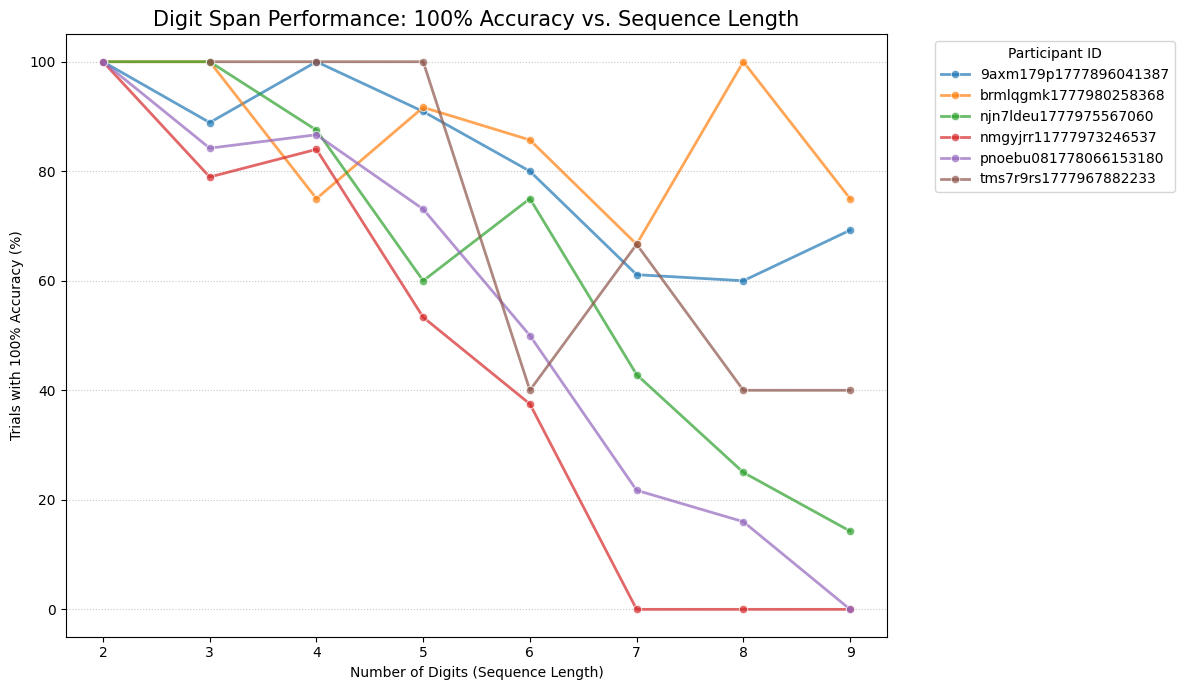

In [13]:

# 3. Aggregation: Per Session
session_summary = df_analyzed.groupby(['uid', 'session']).agg(
    trial_count=('trial_num', 'count'),
    exact_match_pct=('is_exact_match', 'mean'),
    order_acc_mean=('order_acc_pct', 'mean'),
    total_acc_mean=('total_acc_pct', 'mean')
).reset_index()

# 4. Aggregation: Per Participant (Across all 5 sessions)
participant_summary = df_analyzed.groupby('uid').agg(
    avg_exact_match=('is_exact_match', 'mean'),
    avg_positional_acc=('order_acc_pct', 'mean'),
    avg_digit_recall=('total_acc_pct', 'mean')
).reset_index()

# 5. Visualization: Performance by Sequence Length
# This shows the "Span Limit" per participant
viz_data = df_analyzed.groupby(['uid', 'sequence_length'])['is_exact_match'].mean().reset_index()
viz_data['percentage_correct'] = viz_data['is_exact_match'] * 100

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=viz_data, 
    x='sequence_length', 
    y='percentage_correct', 
    hue='uid', 
    marker='o', 
    linewidth=2,
    alpha=0.7
)


plt.title('Digit Span Performance: 100% Accuracy vs. Sequence Length', fontsize=15)
plt.ylabel('Trials with 100% Accuracy (%)')
plt.xlabel('Number of Digits (Sequence Length)')
plt.xticks(range(2, 10))
plt.legend(title='Participant ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig(save_path + '/digit_span_load_analysis.png')

# Save outputs
df_analyzed.to_csv(save_path + '/digit_span_processed.csv', index=False)
session_summary.to_csv(save_path + '/digit_span_session_summary.csv', index=False)

In [12]:
participant_summary

,uid,avg_exact_match,avg_positional_acc,avg_digit_recall
0,9axm179p1777896041387,0.798387,0.907360,0.965694
1,brmlqgmk1777980258368,0.847222,0.898148,0.946649
2,njn7ldeu1777975567060,0.573770,0.763095,0.890593
3,nmgyjrr11777973246537,0.421875,0.714431,0.816555
4,pnoebu081778066153180,0.486111,0.697410,0.853924
5,tms7r9rs1777967882233,0.656250,0.813678,0.913256


In [14]:
# visualizing how many trials each participant had per session
# Calculate the number of tries (rows) per participant and session
try_counts = df.groupby(['uid', 'session']).size().reset_index(name='num_tries')

# View the result
print(try_counts.head())

                     uid  session  num_tries
0  9axm179p1777896041387        1         24
1  9axm179p1777896041387        2         23
2  9axm179p1777896041387        3         25
3  9axm179p1777896041387        4         26
4  9axm179p1777896041387        5         26


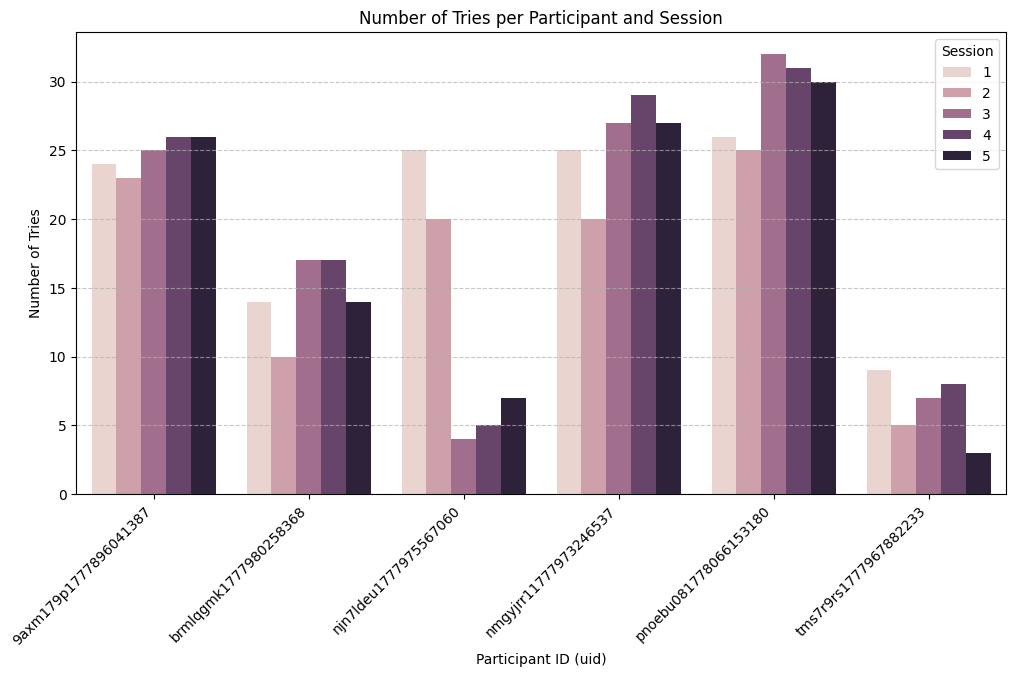

In [16]:
# present it with diagonal labels on x axis
plt.figure(figsize=(12, 6))
sns.barplot(data=try_counts, x='uid', y='num_tries', hue='session')

plt.title('Number of Tries per Participant and Session')
plt.xlabel('Participant ID (uid)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Tries')
plt.legend(title='Session')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(save_path + '/digit_span_tries_per_session.png')
plt.show()